<a href="https://colab.research.google.com/github/Annette-1/SIMULACION-II/blob/main/MH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <span style="color:purple;">**Algoritmo Metropolis-Hastings**</span>
La idea principal es simular una cadena de Markov tal que su distribución estacionaria coincida con la distribución objetivo.

Suponga que deseamos generar una variable una aleatoria $X$ con valores $x={1,...,m}$ de acuerdo a la distribución ${\pi_i}$, $π_i=\frac{b_i}{C}, i\in x$ suponiendo $b_i$ estrictamente positiva, $m$ grande y la constante de normalización $C=∑_{i=1}^∞ b_i$ dificil de calcular.

Construimos una $CM$ ${X_t,t=0,1,...}$ sobre $x$ cuya evolución esté gobernada por la matriz de transición $Q=q_{ij}$ de La siguiente manera:

* Cuando $X_t=i$, generamos $Y$ que satisfaga $P(Y=j)=q_{i,j}$, $j\in X$

* Si $Y=j$, sea



$j$ con probalidad $α_{i,j}=min\{{\frac{\pi_j q_{ji}}{\pi_i q_{ij}}, 1}\}=min\{{\frac{b_j q_{ji}}{b_i q_{ij}}, 1}\}$

$i$ con probalidad $1-α_{i,j}$


Se sigue entonces que $\{X_t, t=0,1,...\}$ tiene una matriz de transicion de un paso $P=p_{i,j}$ dada por
$$ P_{i,j}=
\begin{cases}
q_{ij} α_{ij} \quad si \quad i\neq j \\
1- \sum _{k\neq i} q_{ik} α_{ik} \quad si \quad i = j
\end{cases}
$$

Y se puede probar (Tarea) que, con $\alpha_{i,j}$ definida arriba,
 * Ecuaciones de balance detallado

 $$\pi_i P_{i,j}=\pi_j P_{j,i}\quad i,j\in X$$
 * Ecuaciones de blance

 $$\pi= \pi P$$


 *Seudocódigo*
 * Dada el estado actual $X_t$
 1. Generar $ Y \sim q(X_t,Y )$
 2. Generar $U∼U(0,1)$ y tomar
  $$ X_{t+1}=
\begin{cases}
Y \quad si \quad U\leq α(X,Y)\\
X_t \quad otro \quad caso
\end{cases}
$$

donde $α(x,y)=min \{ ρ(x,y),1\}$ con $ρ(x,y)=\frac{f(y)q(y,x)}{f(x)q(x,y)}$

**$f(x)$ es la función objetivo**

**$q(x,y)$ es una propuesta (se elije simétrica)**
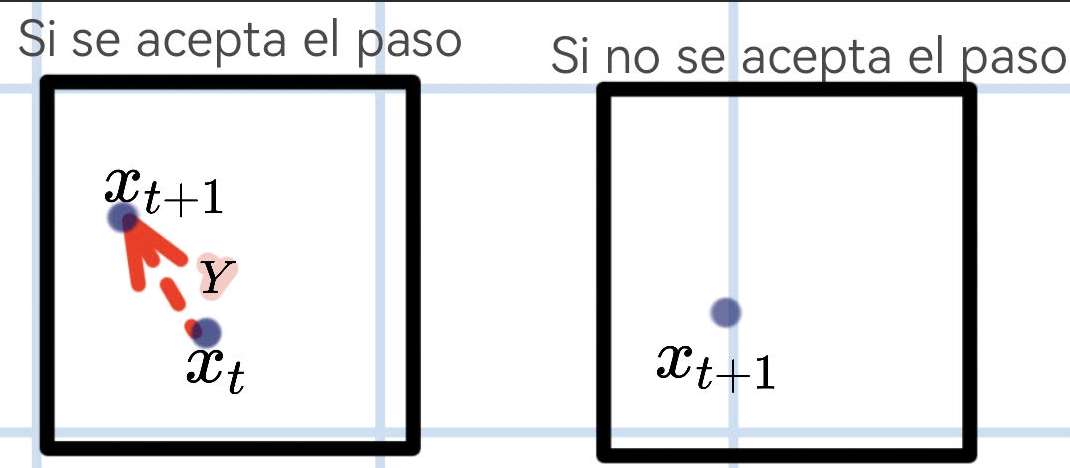


##**Caminata Aleatoria**
Si se elije $q$ como una $N(0,σ)$, se tiene el sampler más simple, con: $$α(x,y)=min\{\frac{f(y)}{f(x)}, 1\} \quad y \quad Y= x+Z \quad Z∼(N(0,σ),N(0,σ)) $$


* **Ejemplo**: Simular el vector $X=(x_1,x_2)$ que sigue el pdf:

$$f(x)= C*exp (-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2})$$

$$C=\frac{1}{20216.335877}$$

**PROGRAMARLO**

*Seudocódigo*
1. Inicialización $X_1=(x_1,x_2).$ Hacer $t=1$
2. Generar $Z_1,Z_2 ∼ N(0,1)$
Sea $Z=Z_1,Z_2$ Y $Y= X_t+Z$
Calcular $α=α(X_t, Y)$
3. Generar $U∼U[0,1]$ sI $U<α.$ Hacer $X_{t+1}=Y$

Otro caso: Hacer $X_{t+1}=X_t$

4. Hacer $t=t+1$. Si $t=N$ (tamaño de la muestra) Detener
Otro caso. Regresar a $2$

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def target_pdf(x):
    x1, x2 = x

    exponent = -(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2
    return np.exp(exponent)


def metropolis_hastings(initial_state, num_samples, proposal_std=1.0):
    samples = np.zeros((num_samples, 2))
    current_state = np.array(initial_state)
    samples[0] = current_state

    for t in range(1, num_samples):

        proposal_step = np.random.normal(0, proposal_std, size=2)
        proposed_state = current_state + proposal_step # Y = X_t + Z

        ratio = target_pdf(proposed_state) / target_pdf(current_state)
        alpha = min(1.0, ratio)


        u = np.random.uniform(0, 1)

        if u < alpha:
            current_state = proposed_state
        samples[t] = current_state

    return samples


In [2]:

initial_state = [0.0, 0.0]
num_samples = 50000
proposal_std = 1.0


simulated_samples = metropolis_hastings(initial_state, num_samples, proposal_std)

print("First 5 simulated samples:")
print(simulated_samples[:5])


First 5 simulated samples:
[[ 0.          0.        ]
 [ 0.          0.        ]
 [-0.26707153  1.15242638]
 [-0.26707153  1.15242638]
 [ 1.13927232  1.09258937]]


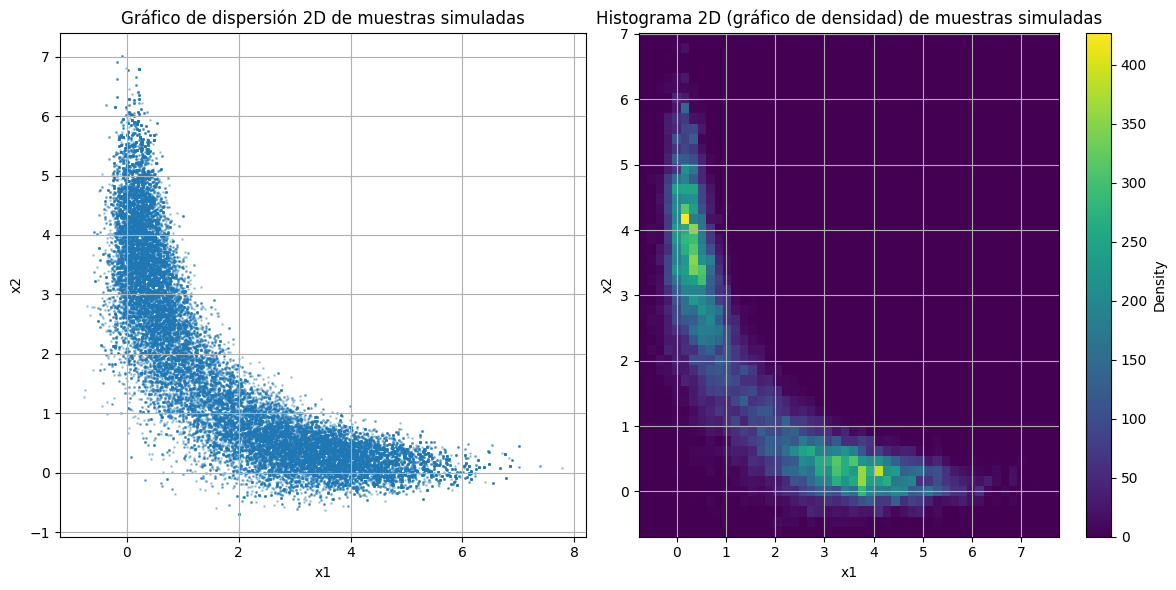

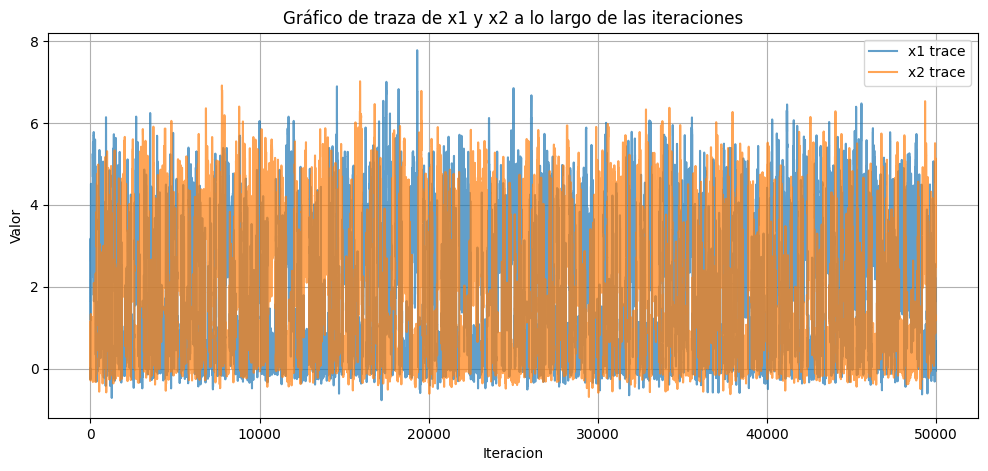

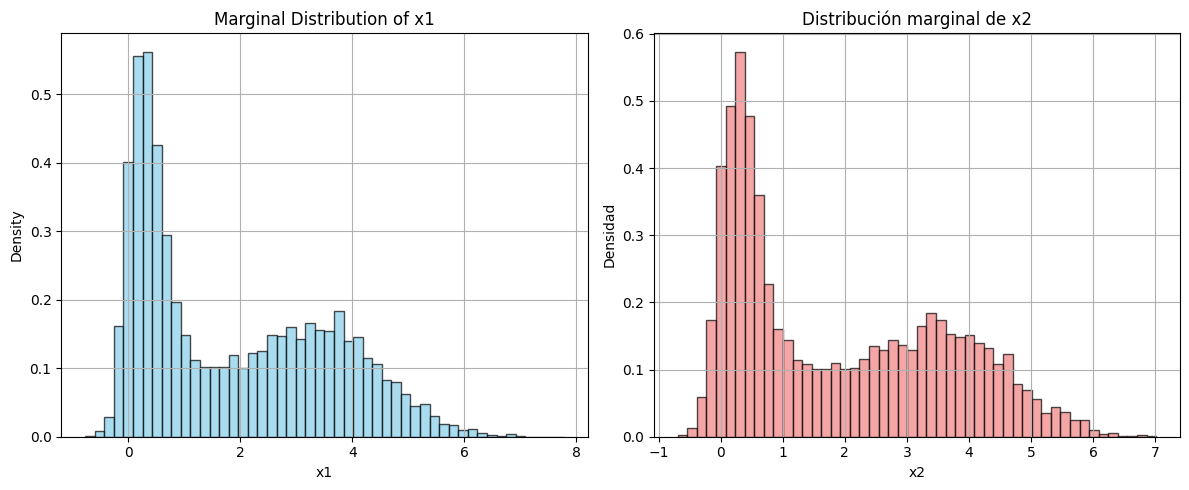

In [5]:

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(simulated_samples[:, 0], simulated_samples[:, 1], alpha=0.3, s=1)
plt.title('Gráfico de dispersión 2D de muestras simuladas')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist2d(simulated_samples[:, 0], simulated_samples[:, 1], bins=50, cmap='viridis')
plt.colorbar(label='Density')
plt.title('Histograma 2D (gráfico de densidad) de muestras simuladas')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(simulated_samples[:, 0], label='x1 trace', alpha=0.7)
plt.plot(simulated_samples[:, 1], label='x2 trace', alpha=0.7)
plt.title('Gráfico de traza de x1 y x2 a lo largo de las iteraciones')
plt.xlabel('Iteracion')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(simulated_samples[:, 0], bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Marginal Distribution of x1')
plt.xlabel('x1')
plt.ylabel('Density')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(simulated_samples[:, 1], bins=50, density=True, alpha=0.7, color='lightcoral', edgecolor='black')
plt.title('Distribución marginal de x2')
plt.xlabel('x2')
plt.ylabel('Densidad')
plt.grid(True)

plt.tight_layout()
plt.show()


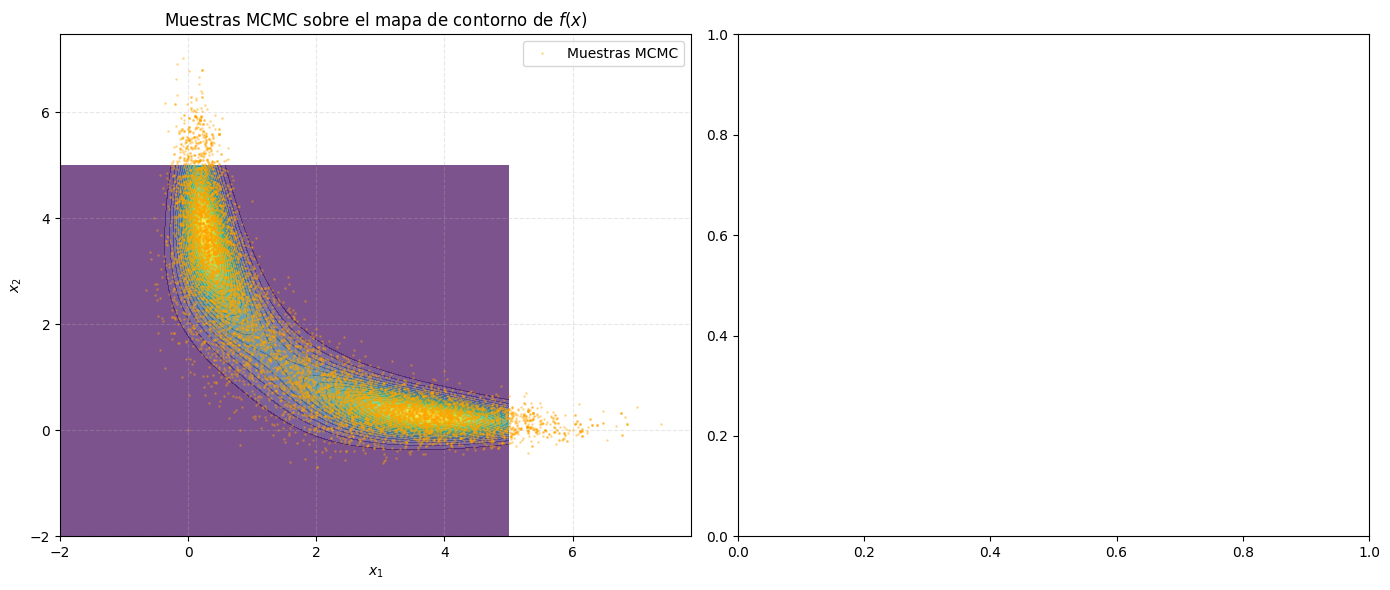

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mapa de Contorno de la Función + Muestras MCMC
x1_grid = np.linspace(-2, 5, 200)
x2_grid = np.linspace(-2, 5, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z = target_pdf([X1, X2]) # Changed 'f' to 'target_pdf'

axes[0].contourf(X1, X2, Z, levels=20, cmap='viridis', alpha=0.7)
axes[0].plot(simulated_samples[::5, 0], simulated_samples[::5, 1], 'o',
             color='orange', markersize=1, alpha=0.3, label='Muestras MCMC') # Changed 'muestras_finales' to 'simulated_samples'
axes[0].set_title('Muestras MCMC sobre el mapa de contorno de $f(x)$')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Poner la moda, la mediana y el promedio